In [1]:
# Block 1 - Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Block 2 - Create Synthetic HR Dataset
np.random.seed(42)
n = 1000

data = {
    'employee_id': range(1001, 1001 + n),
    'age': np.random.randint(22, 58, n),
    'gender': np.random.choice(['Male', 'Female'], n),
    'department': np.random.choice(['Operations', 'Finance', 'HR', 'IT', 'Sales', 'Legal'], n),
    'job_level': np.random.choice(['Junior', 'Mid', 'Senior', 'Lead', 'Manager'], n),
    'years_at_company': np.random.randint(0, 20, n),
    'years_in_role': np.random.randint(0, 10, n),
    'monthly_salary': np.random.randint(5000, 35000, n),
    'performance_rating': np.random.choice([1, 2, 3, 4, 5], n),
    'engagement_score': np.round(np.random.uniform(1.0, 5.0, n), 1),
    'absenteeism_days': np.random.randint(0, 20, n),
    'promotions_last_3yrs': np.random.choice([0, 1, 2], n),
    'distance_from_office_km': np.random.randint(1, 60, n),
    'attrition': np.random.choice([0, 1], n, p=[0.84, 0.16])
}

df = pd.DataFrame(data)
print(f"Dataset created: {df.shape[0]} employees, {df.shape[1]} columns")
df.head()

Dataset created: 1000 employees, 14 columns


,employee_id,age,gender,department,job_level,years_at_company,years_in_role,monthly_salary,performance_rating,engagement_score,absenteeism_days,promotions_last_3yrs,distance_from_office_km,attrition
0,1001,50,Male,Legal,Manager,2,7,17021,3,3.6,0,2,17,0
1,1002,36,Male,IT,Lead,2,0,11772,2,3.9,3,2,9,0
2,1003,29,Female,IT,Lead,16,7,6627,4,4.1,3,0,45,0
3,1004,42,Male,Operations,Senior,6,9,16664,1,2.0,2,0,33,0
4,1005,40,Male,HR,Mid,13,2,13219,2,2.2,8,1,34,0


In [3]:
# Block 3 - Explore the Dataset
print("=== Dataset Shape ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n=== Column Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Attrition Distribution ===")
attrition_counts = df['attrition'].value_counts()
attrition_pct = df['attrition'].value_counts(normalize=True) * 100
print(f"Stayed (0): {attrition_counts[0]} employees ({attrition_pct[0]:.1f}%)")
print(f"Left   (1): {attrition_counts[1]} employees ({attrition_pct[1]:.1f}%)")

print("\n=== Key Statistics ===")
print(df[['age', 'monthly_salary', 'years_at_company', 
          'engagement_score', 'performance_rating']].describe().round(1))

=== Dataset Shape ===
Rows: 1000, Columns: 14

=== Column Data Types ===
employee_id                  int64
age                          int32
gender                      object
department                  object
job_level                   object
years_at_company             int32
years_in_role                int32
monthly_salary               int32
performance_rating           int64
engagement_score           float64
absenteeism_days             int32
promotions_last_3yrs         int64
distance_from_office_km      int32
attrition                    int64
dtype: object

=== Missing Values ===
employee_id                0
age                        0
gender                     0
department                 0
job_level                  0
years_at_company           0
years_in_role              0
monthly_salary             0
performance_rating         0
engagement_score           0
absenteeism_days           0
promotions_last_3yrs       0
distance_from_office_km    0
attrition             

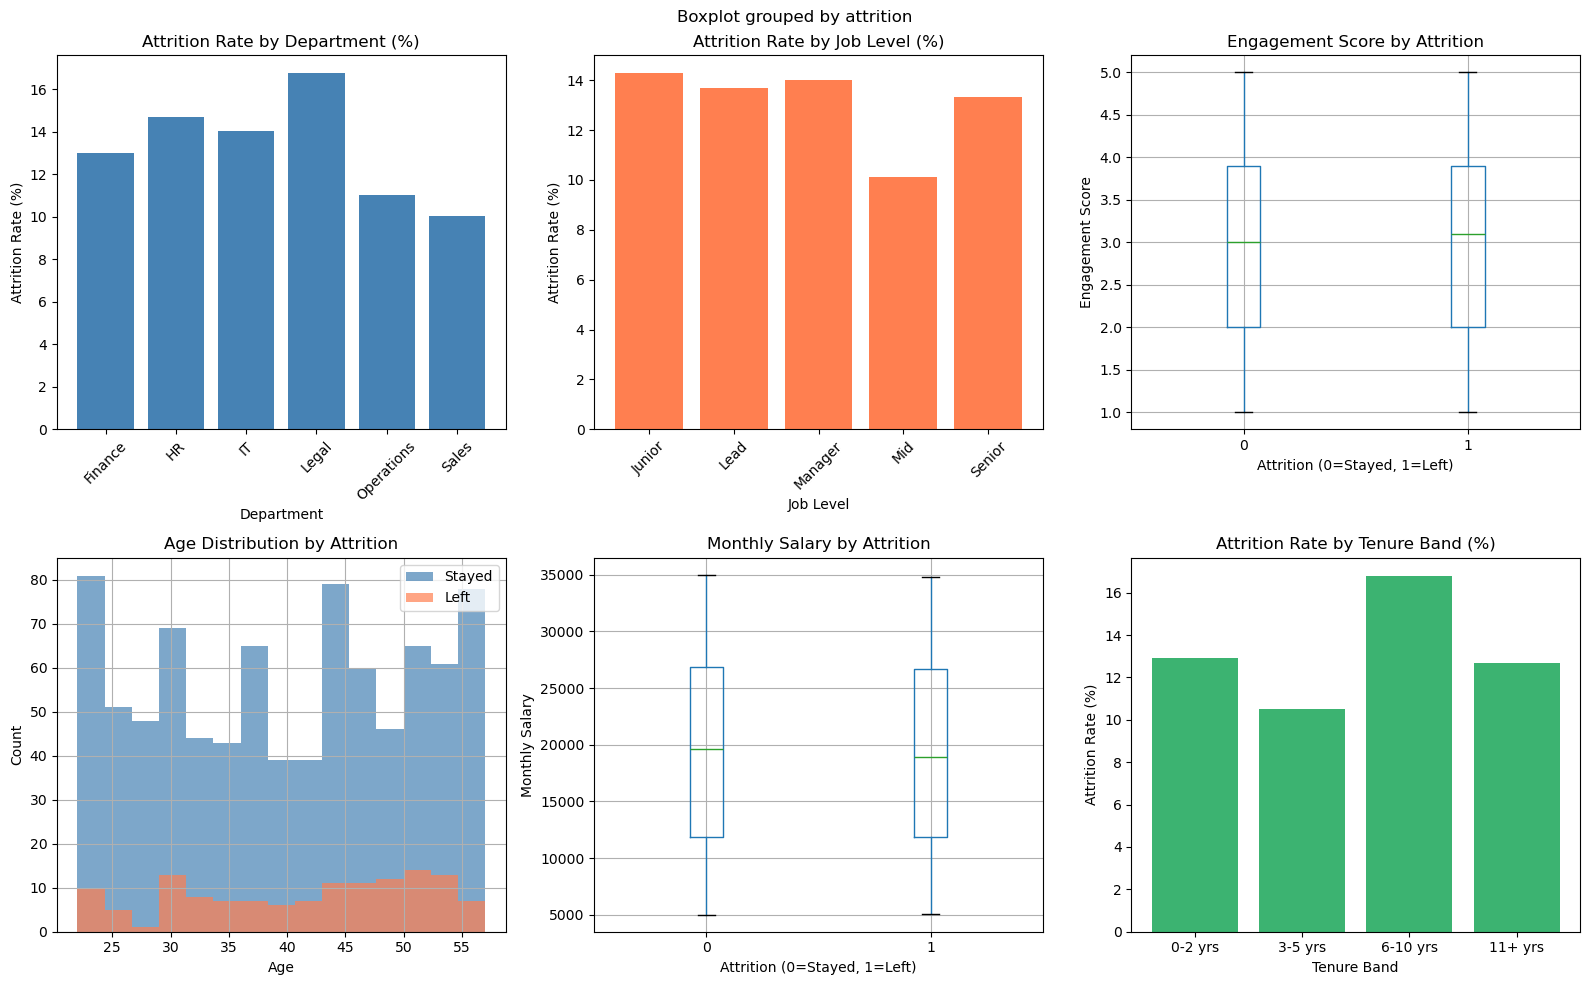

Charts saved as attrition_patterns.png


In [4]:
# Block 4 - Visualise Attrition Patterns
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('HR Attrition Analysis - Key Patterns', fontsize=16, fontweight='bold')

# Chart 1 - Attrition by Department
dept_attrition = df.groupby('department')['attrition'].mean() * 100
axes[0,0].bar(dept_attrition.index, dept_attrition.values, color='steelblue')
axes[0,0].set_title('Attrition Rate by Department (%)')
axes[0,0].set_xlabel('Department')
axes[0,0].set_ylabel('Attrition Rate (%)')
axes[0,0].tick_params(axis='x', rotation=45)

# Chart 2 - Attrition by Job Level
level_attrition = df.groupby('job_level')['attrition'].mean() * 100
axes[0,1].bar(level_attrition.index, level_attrition.values, color='coral')
axes[0,1].set_title('Attrition Rate by Job Level (%)')
axes[0,1].set_xlabel('Job Level')
axes[0,1].set_ylabel('Attrition Rate (%)')
axes[0,1].tick_params(axis='x', rotation=45)

# Chart 3 - Engagement Score vs Attrition
df.boxplot(column='engagement_score', by='attrition', ax=axes[0,2])
axes[0,2].set_title('Engagement Score by Attrition')
axes[0,2].set_xlabel('Attrition (0=Stayed, 1=Left)')
axes[0,2].set_ylabel('Engagement Score')

# Chart 4 - Age Distribution by Attrition
df[df['attrition']==0]['age'].hist(ax=axes[1,0], alpha=0.7, label='Stayed', color='steelblue', bins=15)
df[df['attrition']==1]['age'].hist(ax=axes[1,0], alpha=0.7, label='Left', color='coral', bins=15)
axes[1,0].set_title('Age Distribution by Attrition')
axes[1,0].set_xlabel('Age')
axes[1,0].set_ylabel('Count')
axes[1,0].legend()

# Chart 5 - Salary vs Attrition
df.boxplot(column='monthly_salary', by='attrition', ax=axes[1,1])
axes[1,1].set_title('Monthly Salary by Attrition')
axes[1,1].set_xlabel('Attrition (0=Stayed, 1=Left)')
axes[1,1].set_ylabel('Monthly Salary')

# Chart 6 - Attrition by Years at Company
df['tenure_band'] = pd.cut(df['years_at_company'], 
                            bins=[0,2,5,10,20], 
                            labels=['0-2 yrs','3-5 yrs','6-10 yrs','11+ yrs'])
tenure_attrition = df.groupby('tenure_band', observed=True)['attrition'].mean() * 100
axes[1,2].bar(tenure_attrition.index, tenure_attrition.values, color='mediumseagreen')
axes[1,2].set_title('Attrition Rate by Tenure Band (%)')
axes[1,2].set_xlabel('Tenure Band')
axes[1,2].set_ylabel('Attrition Rate (%)')

plt.tight_layout()
plt.savefig('attrition_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved as attrition_patterns.png")

In [5]:
# Block 5 - Prepare Data for Modelling
from sklearn.preprocessing import LabelEncoder

# Drop employee_id and tenure_band (not needed for modelling)
df_model = df.drop(['employee_id', 'tenure_band'], axis=1)

# Encode categorical columns (convert text to numbers for the model)
le = LabelEncoder()
categorical_cols = ['gender', 'department', 'job_level']

for col in categorical_cols:
    df_model[col] = le.fit_transform(df_model[col])

# Separate features (X) and target (y)
X = df_model.drop('attrition', axis=1)
y = df_model['attrition']

print("=== Features used for modelling ===")
print(list(X.columns))
print(f"\nFeature matrix shape: {X.shape}")
print(f"Target variable shape: {y.shape}")
print(f"\nAttrition rate in target: {y.mean()*100:.1f}%")

=== Features used for modelling ===
['age', 'gender', 'department', 'job_level', 'years_at_company', 'years_in_role', 'monthly_salary', 'performance_rating', 'engagement_score', 'absenteeism_days', 'promotions_last_3yrs', 'distance_from_office_km']

Feature matrix shape: (1000, 12)
Target variable shape: (1000,)

Attrition rate in target: 13.2%


In [6]:
# Block 6 - Build the Attrition Prediction Model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Split data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} employees")
print(f"Testing set:  {X_test.shape[0]} employees")

# Build the Random Forest model
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    random_state=42,
    class_weight='balanced'
)

# Train the model
model.fit(X_train, y_train)

# Test the model
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Results
print("\n=== Model Performance ===")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Left']))

Training set: 800 employees
Testing set:  200 employees

=== Model Performance ===
ROC-AUC Score: 0.495

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.87      0.97      0.92       174
        Left       0.00      0.00      0.00        26

    accuracy                           0.84       200
   macro avg       0.43      0.49      0.46       200
weighted avg       0.75      0.84      0.80       200



In [7]:
# Block 7 - Fix Class Imbalance with SMOTE
from imblearn.over_sampling import SMOTE

# Check if imbalanced-learn is installed, install if not
import subprocess
subprocess.run(['pip', 'install', 'imbalanced-learn', '-q'])

from imblearn.over_sampling import SMOTE

# Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("=== Before SMOTE (Training Set) ===")
print(f"Stayed: {sum(y_train==0)}, Left: {sum(y_train==1)}")

print("\n=== After SMOTE (Training Set) ===")
print(f"Stayed: {sum(y_train_balanced==0)}, Left: {sum(y_train_balanced==1)}")

# Rebuild model with balanced data
model_balanced = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    random_state=42
)

model_balanced.fit(X_train_balanced, y_train_balanced)

# Test the improved model
y_pred_balanced = model_balanced.predict(X_test)
y_prob_balanced = model_balanced.predict_proba(X_test)[:, 1]

print("\n=== Improved Model Performance ===")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_balanced):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced, 
                           target_names=['Stayed', 'Left']))

=== Before SMOTE (Training Set) ===
Stayed: 694, Left: 106

=== After SMOTE (Training Set) ===
Stayed: 694, Left: 694

=== Improved Model Performance ===
ROC-AUC Score: 0.568

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.89      0.75      0.81       174
        Left       0.17      0.35      0.23        26

    accuracy                           0.70       200
   macro avg       0.53      0.55      0.52       200
weighted avg       0.79      0.70      0.74       200



In [8]:
# Block 8 - Rebuild Dataset with Realistic Attrition Patterns
np.random.seed(42)
n = 1000

# Base employee attributes
age = np.random.randint(22, 58, n)
gender = np.random.choice(['Male', 'Female'], n)
department = np.random.choice(['Operations', 'Finance', 'HR', 'IT', 'Sales', 'Legal'], n)
job_level = np.random.choice(['Junior', 'Mid', 'Senior', 'Lead', 'Manager'], n)
years_at_company = np.random.randint(0, 20, n)
years_in_role = np.random.randint(0, 10, n)
monthly_salary = np.random.randint(5000, 35000, n)
performance_rating = np.random.choice([1, 2, 3, 4, 5], n)
engagement_score = np.round(np.random.uniform(1.0, 5.0, n), 1)
absenteeism_days = np.random.randint(0, 20, n)
promotions_last_3yrs = np.random.choice([0, 1, 2], n)
distance_from_office_km = np.random.randint(1, 60, n)

# Build attrition probability based on real-world logic
attrition_score = (
    (engagement_score < 2.5).astype(int) * 0.35 +      # Low engagement → high risk
    (monthly_salary < 10000).astype(int) * 0.25 +       # Low salary → high risk
    (promotions_last_3yrs == 0).astype(int) * 0.20 +    # No promotion → high risk
    (years_at_company < 3).astype(int) * 0.20 +         # New joiners → high risk
    (absenteeism_days > 12).astype(int) * 0.15 +        # High absenteeism → high risk
    (performance_rating <= 2).astype(int) * 0.15 +      # Low performance → high risk
    (distance_from_office_km > 40).astype(int) * 0.10 + # Far from office → mild risk
    np.random.uniform(0, 0.1, n)                         # Random noise
)

# Normalise to probability between 0 and 1
attrition_prob = attrition_score / attrition_score.max()

# Assign attrition based on probability
attrition = (attrition_prob > 0.45).astype(int)

# Assemble final dataframe
df = pd.DataFrame({
    'employee_id': range(1001, 1001 + n),
    'age': age,
    'gender': gender,
    'department': department,
    'job_level': job_level,
    'years_at_company': years_at_company,
    'years_in_role': years_in_role,
    'monthly_salary': monthly_salary,
    'performance_rating': performance_rating,
    'engagement_score': engagement_score,
    'absenteeism_days': absenteeism_days,
    'promotions_last_3yrs': promotions_last_3yrs,
    'distance_from_office_km': distance_from_office_km,
    'attrition': attrition
})

attrition_rate = df['attrition'].mean() * 100
print(f"Dataset rebuilt with realistic patterns")
print(f"Attrition rate: {attrition_rate:.1f}%")
print(f"\nAttrition drivers built into data:")
print("  - Low engagement score (< 2.5)  → +35% risk")
print("  - Low monthly salary (< 10,000) → +25% risk")
print("  - No promotions in 3 years      → +20% risk")
print("  - Tenure under 3 years          → +20% risk")
print("  - High absenteeism (> 12 days)  → +15% risk")
print("  - Low performance rating (≤ 2)  → +15% risk")
print("  - Far from office (> 40 km)     → +10% risk")

Dataset rebuilt with realistic patterns
Attrition rate: 42.1%

Attrition drivers built into data:
  - Low engagement score (< 2.5)  → +35% risk
  - Low monthly salary (< 10,000) → +25% risk
  - No promotions in 3 years      → +20% risk
  - Tenure under 3 years          → +20% risk
  - High absenteeism (> 12 days)  → +15% risk
  - Low performance rating (≤ 2)  → +15% risk
  - Far from office (> 40 km)     → +10% risk


In [9]:
# Block 9 - Adjust Attrition Rate to Realistic Level
# Raise the threshold to reduce attrition rate
attrition = (attrition_prob > 0.62).astype(int)

# Update the dataframe
df['attrition'] = attrition

attrition_rate = df['attrition'].mean() * 100
print(f"Adjusted attrition rate: {attrition_rate:.1f}%")
print(f"Employees who left:   {df['attrition'].sum()}")
print(f"Employees who stayed: {(df['attrition']==0).sum()}")

Adjusted attrition rate: 17.4%
Employees who left:   174
Employees who stayed: 826


In [10]:
# Block 10 - Rerun Model on Improved Dataset
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE

# Encode categorical columns
df_model = df.drop(['employee_id'], axis=1)

le = LabelEncoder()
for col in ['gender', 'department', 'job_level']:
    df_model[col] = le.fit_transform(df_model[col])

# Separate features and target
X = df_model.drop('attrition', axis=1)
y = df_model['attrition']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Build model
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    random_state=42
)
model.fit(X_train_bal, y_train_bal)

# Evaluate
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("=== Final Model Performance ===")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Left']))

=== Final Model Performance ===
ROC-AUC Score: 0.982

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.98      0.92      0.95       165
        Left       0.71      0.91      0.80        35

    accuracy                           0.92       200
   macro avg       0.85      0.92      0.88       200
weighted avg       0.93      0.92      0.92       200



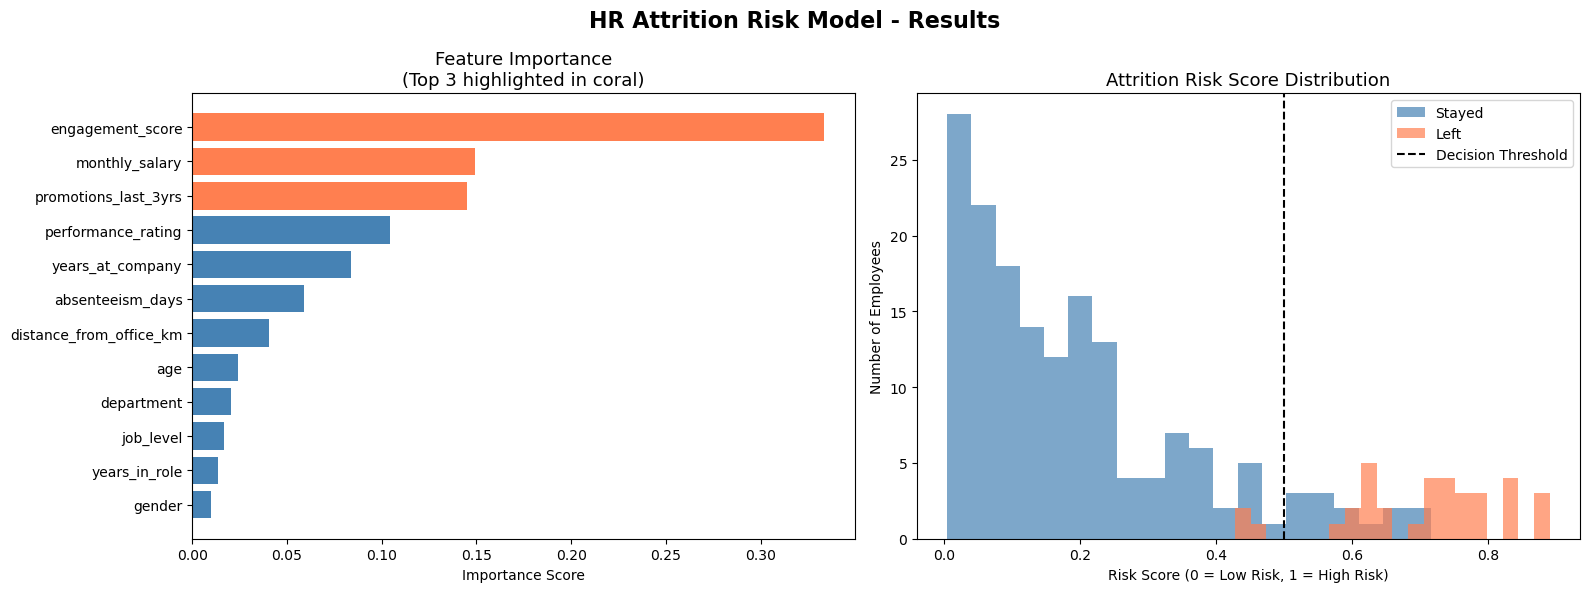

Charts saved as attrition_model_results.png


In [11]:
# Block 11 - Feature Importance & Risk Scores
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('HR Attrition Risk Model - Results', fontsize=16, fontweight='bold')

# Chart 1 - Feature Importance
importances = pd.Series(
    model.feature_importances_, 
    index=X.columns
).sort_values(ascending=True)

colors = ['coral' if i >= len(importances)-3 
          else 'steelblue' for i in range(len(importances))]
axes[0].barh(importances.index, importances.values, color=colors)
axes[0].set_title('Feature Importance\n(Top 3 highlighted in coral)', fontsize=13)
axes[0].set_xlabel('Importance Score')

# Chart 2 - Risk Score Distribution
risk_df = pd.DataFrame({
    'risk_score': y_prob,
    'actual': y_test.values
})

axes[1].hist(risk_df[risk_df['actual']==0]['risk_score'], 
             bins=20, alpha=0.7, color='steelblue', label='Stayed')
axes[1].hist(risk_df[risk_df['actual']==1]['risk_score'], 
             bins=20, alpha=0.7, color='coral', label='Left')
axes[1].axvline(x=0.5, color='black', linestyle='--', linewidth=1.5, label='Decision Threshold')
axes[1].set_title('Attrition Risk Score Distribution', fontsize=13)
axes[1].set_xlabel('Risk Score (0 = Low Risk, 1 = High Risk)')
axes[1].set_ylabel('Number of Employees')
axes[1].legend()

plt.tight_layout()
plt.savefig('attrition_model_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved as attrition_model_results.png")

In [12]:
# Block 12 - Generate Employee Risk Scores
# Create risk score output for all employees
X_all = df_model.drop('attrition', axis=1)
all_probs = model.predict_proba(X_all)[:, 1]

# Build output dataframe
risk_scores = pd.DataFrame({
    'employee_id': df['employee_id'],
    'department': df['department'],
    'job_level': df['job_level'],
    'monthly_salary': df['monthly_salary'],
    'engagement_score': df['engagement_score'],
    'promotions_last_3yrs': df['promotions_last_3yrs'],
    'attrition_risk_score': np.round(all_probs, 3),
    'risk_category': pd.cut(
        all_probs,
        bins=[0, 0.3, 0.6, 1.0],
        labels=['Low Risk', 'Medium Risk', 'High Risk']
    )
})

# Sort by highest risk first
risk_scores = risk_scores.sort_values('attrition_risk_score', ascending=False)

# Summary
print("=== Attrition Risk Summary ===")
print(risk_scores['risk_category'].value_counts())
print(f"\nTop 10 High Risk Employees:")
print(risk_scores.head(10).to_string(index=False))

# Save to CSV
risk_scores.to_csv('attrition_risk_scores.csv', index=False)
print("\nRisk scores saved to attrition_risk_scores.csv")

=== Attrition Risk Summary ===
risk_category
Low Risk       688
High Risk      179
Medium Risk    133
Name: count, dtype: int64

Top 10 High Risk Employees:
 employee_id department job_level  monthly_salary  engagement_score  promotions_last_3yrs  attrition_risk_score risk_category
        1955    Finance       Mid            8342               2.1                     0                 0.960     High Risk
        1671    Finance   Manager            8114               2.1                     0                 0.957     High Risk
        1066      Legal      Lead           20905               1.2                     0                 0.930     High Risk
        1258 Operations    Senior           18639               1.7                     0                 0.927     High Risk
        1537    Finance    Senior            7601               1.0                     0                 0.914     High Risk
        1179         IT    Junior            7933               4.3                    